# Wine Quality Prediction

## Objective

Train and compare multiple classification models to predict wine quality based on its physicochemical properties.

## Workflow

- Load and inspect the Wine Quality dataset
- Analyze quality score distribution
- Perform exploratory data analysis
- Discuss class imbalance
- Convert quality scores into Low, Medium, and High classes
- Perform a stratified train-test split
- Train Random Forest, SGD, and SVC classifiers
- Evaluate model performance
- Analyze Random Forest feature importance
- Compare all three models
- Identify the most suitable model for deployment

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Load Dataset

In [2]:
df = pd.read_csv("../Data/Raw/winequality-red.csv", sep=";")

## Initial Data Inspection

In [3]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
df.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5
1598,6.0,0.310,0.47,3.6,0.067,18.0,42.0,0.99549,3.39,0.66,11.0,6


In [5]:
df.shape

(1599, 12)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [7]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [8]:
duplicate_count = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_count)

Number of Duplicate Rows: 240


## Duplicate Value Analysis

The dataset contains 240 duplicate rows. These duplicate records can affect model training by giving repeated observations more influence. Since the goal is to build a classification model based on unique wine samples, the duplicate rows will be removed before further analysis and modelling.

In [9]:
df = df.drop_duplicates().reset_index(drop=True)

print("Dataset Shape After Removing Duplicates:", df.shape)
print("Remaining Duplicate Rows:", df.duplicated().sum())

Dataset Shape After Removing Duplicates: (1359, 12)
Remaining Duplicate Rows: 0


## Quality Score Distribution

In [10]:
quality_counts = df["quality"].value_counts().sort_index()
quality_counts

quality
3     10
4     53
5    577
6    535
7    167
8     17
Name: count, dtype: int64

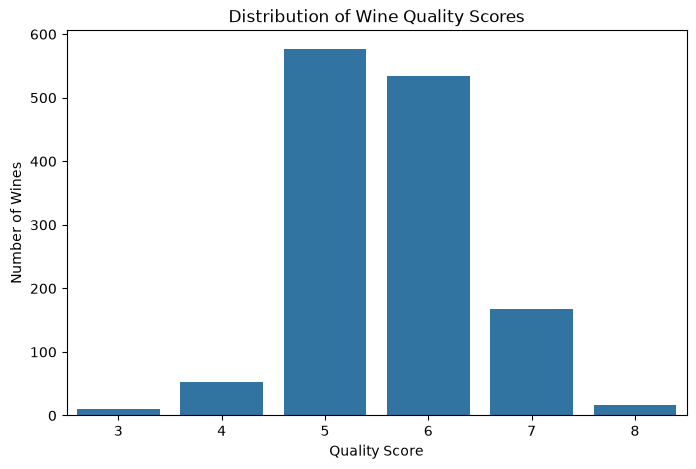

In [11]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="quality")

plt.title("Distribution of Wine Quality Scores")
plt.xlabel("Quality Score")
plt.ylabel("Number of Wines")
plt.show()

## Exploratory Data Analysis

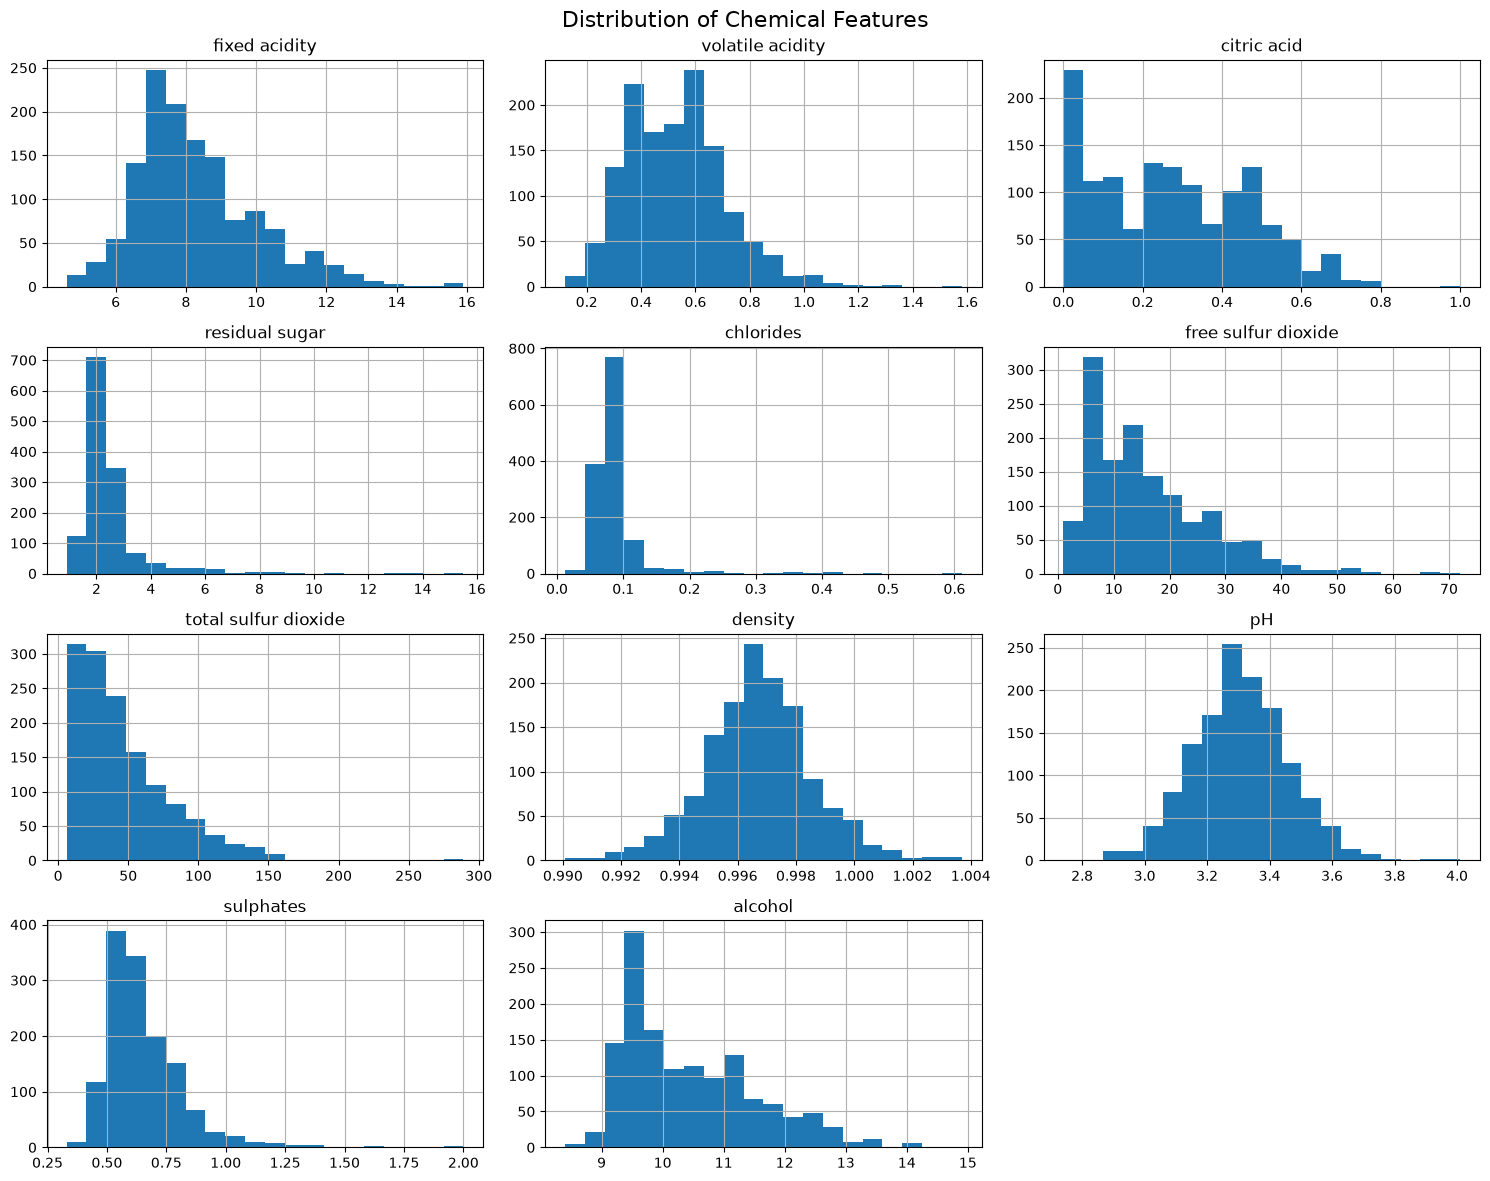

In [12]:
chemical_features = df.columns.drop("quality")

df[chemical_features].hist(figsize=(15, 12), bins=20)

plt.suptitle("Distribution of Chemical Features", fontsize=16)
plt.tight_layout()
plt.show()

## Correlation Heatmap

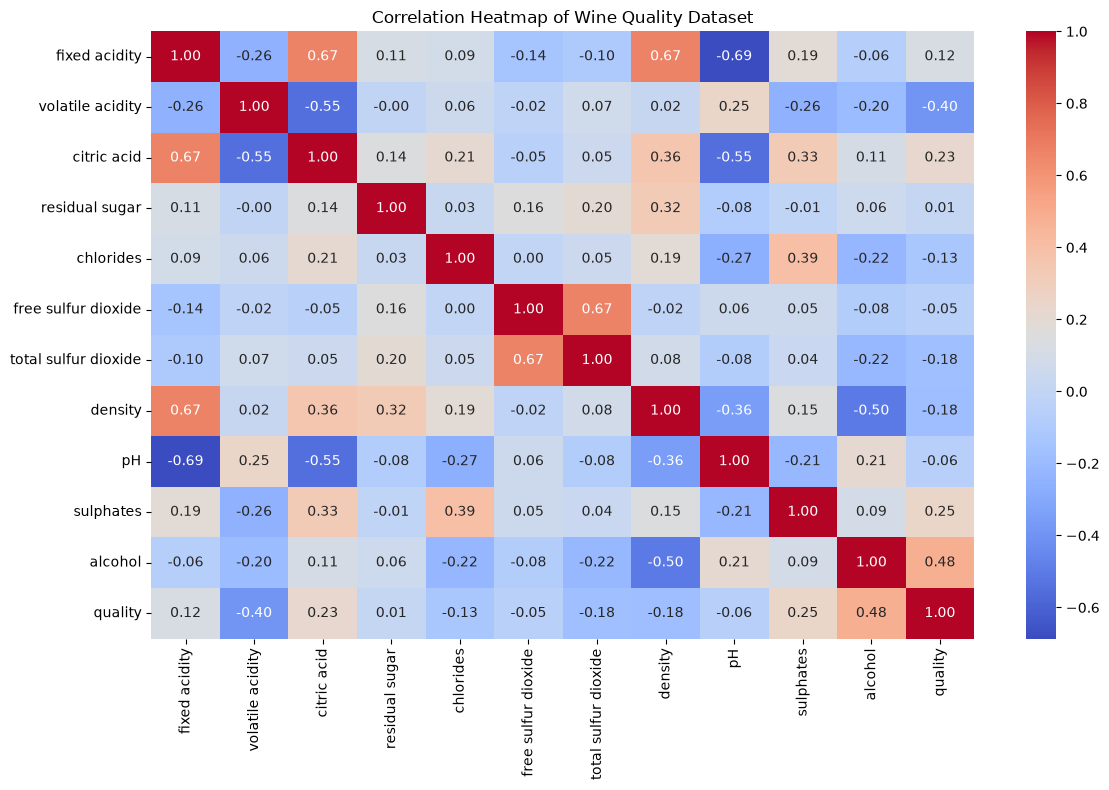

In [13]:
plt.figure(figsize=(12, 8))

correlation_matrix = df.corr()

sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Correlation Heatmap of Wine Quality Dataset")
plt.tight_layout()
plt.show()

## Class Imbalance Analysis

The quality scores are not evenly distributed. Quality scores 5 and 6 represent the majority of the observations, while scores 3, 4, and 8 are underrepresented.

This class imbalance can affect classification performance because models may learn the majority classes more effectively than the minority classes. Therefore, the imbalance should be considered when evaluating model performance.

In [14]:
quality_counts = df["quality"].value_counts().sort_index()

class_distribution = pd.DataFrame({
    "Quality Score": quality_counts.index,
    "Count": quality_counts.values,
    "Percentage": (quality_counts.values / len(df) * 100).round(2)
})

class_distribution

,Quality Score,Count,Percentage
0,3,10,0.74
1,4,53,3.90
2,5,577,42.46
3,6,535,39.37
4,7,167,12.29
5,8,17,1.25


## Feature Engineering: Quality Score Binning

The original quality scores are converted into three classification categories:

- Low: quality scores 3 and 4
- Medium: quality scores 5 and 6
- High: quality scores 7 and 8

A three-class approach was selected instead of binary classification because it preserves more information from the original quality scores. It distinguishes low-quality, medium-quality, and high-quality wines while simplifying the prediction problem into manageable categories.

The original numerical `quality` column is retained for reference, while `quality_category` is used as the classification target.

In [15]:
def quality_category(score):
    if score <= 4:
        return "Low"
    elif score <= 6:
        return "Medium"
    else:
        return "High"

df["quality_category"] = df["quality"].apply(quality_category)

df["quality_category"].value_counts()

quality_category
Medium    1112
High       184
Low         63
Name: count, dtype: int64

## Class Distribution After Feature Engineering

In [16]:
class_counts = df["quality_category"].value_counts()

class_counts

quality_category
Medium    1112
High       184
Low         63
Name: count, dtype: int64

## Prepare Features and Target

The physicochemical properties are used as input features, while `quality_category` is used as the target variable.

The original numerical `quality` column is excluded from the features because it directly represents the target information.

In [17]:
X = df.drop(columns=["quality", "quality_category"])
y = df["quality_category"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (1359, 11)
Target Shape: (1359,)


- The physicochemical properties are used as input features, while `quality_category` is used as the target variable.

- The original numerical `quality` column is excluded from the features because it directly represents the target information.

## Stratified Train-Test Split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)
print("Training Class Distribution:")
print(y_train.value_counts(normalize=True).round(3))
print("Testing Class Distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training Set: (1087, 11)
Testing Set: (272, 11)
Training Class Distribution:
quality_category
Medium    0.819
High      0.135
Low       0.046
Name: proportion, dtype: float64
Testing Class Distribution:
quality_category
Medium    0.816
High      0.136
Low       0.048
Name: proportion, dtype: float64


## Random Forest Classifier

In [19]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy:", round(rf_accuracy, 4))

Random Forest Accuracy: 0.8199


## Stochastic Gradient Descent Classifier (SGD) 

In [20]:
sgd_model = SGDClassifier(
    random_state=42,
    max_iter=1000,
    tol=1e-3
)

sgd_model.fit(X_train, y_train)

sgd_predictions = sgd_model.predict(X_test)

sgd_accuracy = accuracy_score(y_test, sgd_predictions)

print("SGD Accuracy:", round(sgd_accuracy, 4))

SGD Accuracy: 0.8162


## Support Vector Classifier

In [21]:
svc_model = SVC(
    random_state=42
)

svc_model.fit(X_train, y_train)

svc_predictions = svc_model.predict(X_test)

svc_accuracy = accuracy_score(y_test, svc_predictions)

print("SVC Accuracy:", round(svc_accuracy, 4))

SVC Accuracy: 0.8162


## Classification Reports

In [22]:
print("Random Forest Classification Report")
print(classification_report(y_test, rf_predictions, zero_division=0))

print("SGD Classification Report")
print(classification_report(y_test, sgd_predictions, zero_division=0))

print("SVC Classification Report")
print(classification_report(y_test, svc_predictions, zero_division=0))

Random Forest Classification Report
              precision    recall  f1-score   support

        High       0.57      0.32      0.41        37
         Low       0.33      0.15      0.21        13
      Medium       0.85      0.94      0.90       222

    accuracy                           0.82       272
   macro avg       0.59      0.47      0.51       272
weighted avg       0.79      0.82      0.80       272

SGD Classification Report
              precision    recall  f1-score   support

        High       0.00      0.00      0.00        37
         Low       0.00      0.00      0.00        13
      Medium       0.82      1.00      0.90       222

    accuracy                           0.82       272
   macro avg       0.27      0.33      0.30       272
weighted avg       0.67      0.82      0.73       272

SVC Classification Report
              precision    recall  f1-score   support

        High       0.00      0.00      0.00        37
         Low       0.00      0.00      0.

## Confusion Matrices

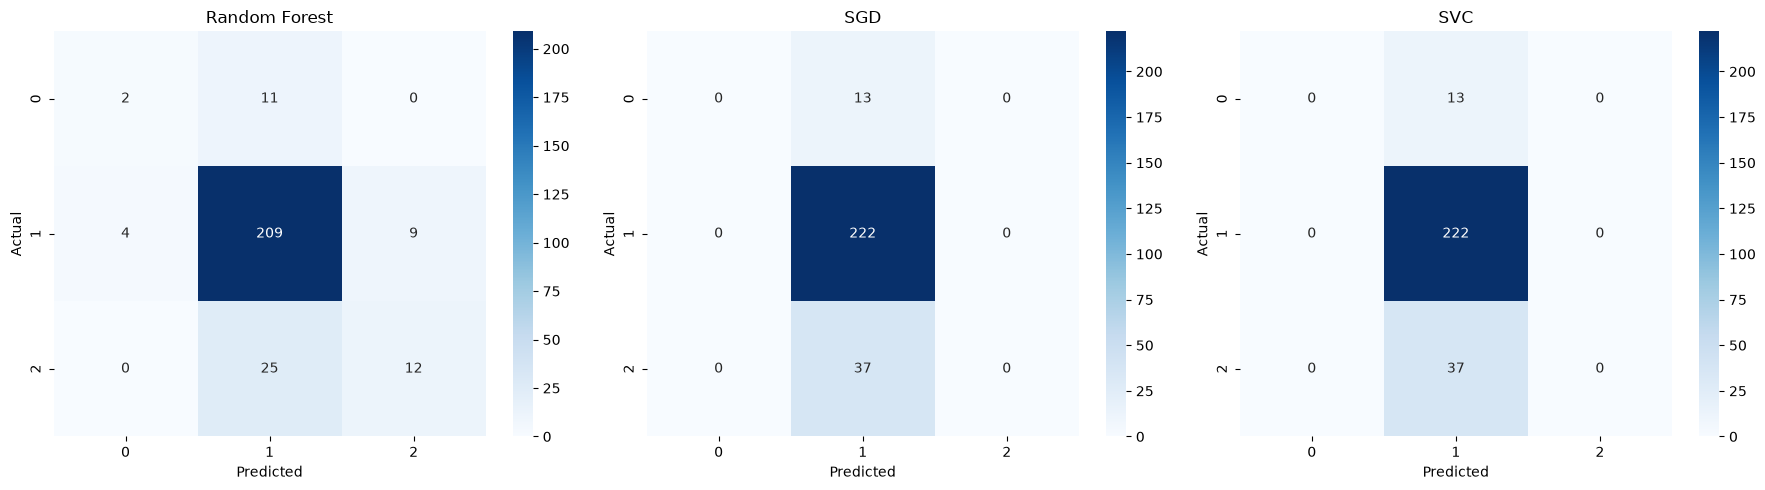

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = {
    "Random Forest": rf_predictions,
    "SGD": sgd_predictions,
    "SVC": svc_predictions
}

for ax, (name, predictions) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, predictions, labels=["Low", "Medium", "High"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

## Random Forest Feature Importance

In [27]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance

feature_importance_table = pd.DataFrame({
    "Chemical Feature": feature_importance.index,
    "Importance": feature_importance.values
}).reset_index(drop=True)

feature_importance_table["Importance"] = feature_importance_table["Importance"].round(4)

feature_importance_table

,Chemical Feature,Importance
0,alcohol,0.1517
1,volatile acidity,0.1174
2,sulphates,0.1132
3,density,0.0910
4,total sulfur dioxide,0.0892
5,citric acid,0.0821
6,fixed acidity,0.0790
7,residual sugar,0.0765
8,chlorides,0.0697
9,pH,0.0684


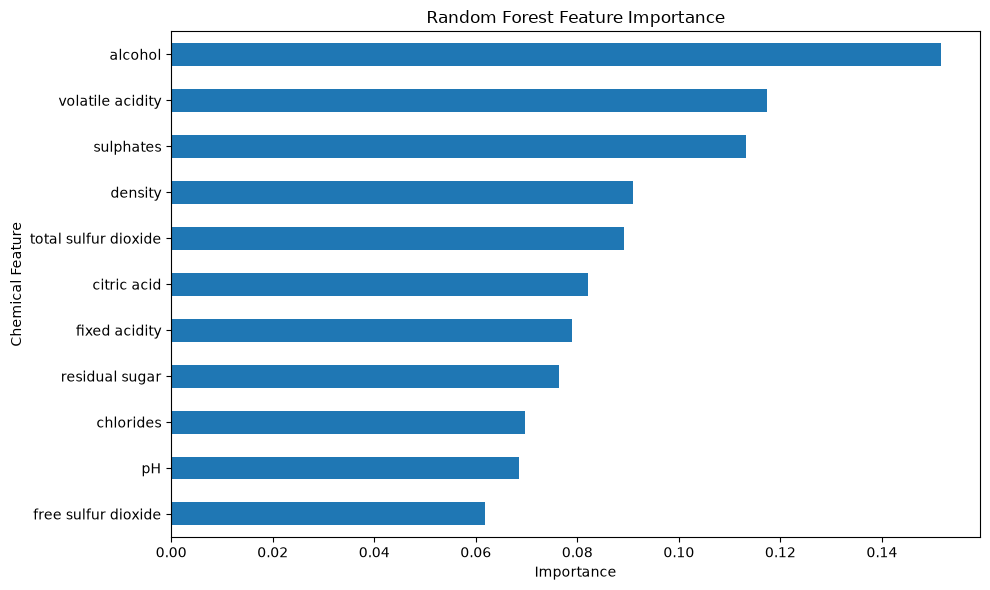

In [25]:
plt.figure(figsize=(10, 6))

feature_importance.sort_values().plot(kind="barh")

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Chemical Feature")
plt.tight_layout()
plt.show()

## Model Comparison

In [29]:
from sklearn.metrics import f1_score

comparison_table = pd.DataFrame({
    "Model": ["Random Forest", "SGD", "SVC"],
    "Accuracy": [
        accuracy_score(y_test, rf_predictions),
        accuracy_score(y_test, sgd_predictions),
        accuracy_score(y_test, svc_predictions)
    ],
    "Macro F1-Score": [
        f1_score(y_test, rf_predictions, average="macro"),
        f1_score(y_test, sgd_predictions, average="macro"),
        f1_score(y_test, svc_predictions, average="macro")
    ]
})

comparison_table["Accuracy"] = comparison_table["Accuracy"].round(4)
comparison_table["Macro F1-Score"] = comparison_table["Macro F1-Score"].round(4)

comparison_table

,Model,Accuracy,Macro F1-Score
0,Random Forest,0.8199,0.5065
1,SGD,0.8162,0.2996
2,SVC,0.8162,0.2996


## Best Model Analysis

Random Forest achieved the highest accuracy of 81.99% and the highest macro F1-score of 0.5065 among the three models.

Although SGD and SVC achieved similar accuracy scores of 81.62%, their macro F1-scores were considerably lower at 0.2996. Their classification reports and confusion matrices also showed difficulty in identifying the Low and High quality classes.

Random Forest therefore provides the best overall balance between accuracy and performance across the three quality categories.

## Conclusion and Deployment Recommendation

Random Forest is the most suitable model for deployment among the three tested classifiers. It achieved the highest accuracy and macro F1-score and was better at identifying the minority Low and High quality classes.

However, the class imbalance remains an important limitation. The model performs much better on the Medium class than on the minority classes, so further improvements such as class balancing, additional feature engineering, and hyperparameter tuning could improve performance before production deployment.